#Arboles de decisión

Un *árbol de decisión* es un algoritmo de aprendizaje supervisado no paramétrico, que se utiliza tanto para tareas de clasificación como de regresión. Tiene una estructura jerarquica de árbol. Este divide iterativamente el espacio de predictores en regiones más homogeneas mediante nodos y hojas.

Para este caso se va a trabajar sobre una base de datos con el fin de predecir la deserción o el éxito académico del estudiante y el rendimiento académico de los estudiantes al final del primer y segundo cuatrimestre.

## Exploración de datos

En el dataset se tienen 37 variables, en principio la variable que me va a garantizar si el estudiante se graduara a fin de curso es la columna de *Target*, el cual tiene 3 clases, *Enrolled*, *Dropout*, y *Graduate*, por lo tanto, vamos a considerar únicamente la clase *Graduate* para hacer la clasificación binaria de si el estudiante se gradua a fin de clase o no.

Se distinguen dos tipos de variables categoricas, las variables nominales y las variables ordinales.
Las primeras son aquellas cuyas categorías no tienen un orden expecifico. En el dataset se clasifico las siguientes como nominales:


*   *Marital Status*
*   *Application mode*
*   *Course*
*   *Nacionality*
*    *Mother's occupation*
*    *Father's occupation*
*    *Previous qualification*
*   *Etc*

Mientras que el resto son los correspondientes a los ordinales, el cual sus categorías tienen un orden natural, aunque no haya una cuantificación de forma númerica exacta.

Las variables nominales se codificaran mediante **One-Hot Enconding**, el cual genera columnas binarias independientes para cada una de sus categorías. Mientras que las variables ordinales como ya tienen un orden lógico se dejaran como están. Luego se aplica *train_test_split* sobre el *DataFrame*, reservando el 25% de los casos para prueba y garantizando que la proporción de graduados y no graduados se mantenga de forma lineal en ambos conjuntos, de modo que la evaluación no sea sesgada. Esto lo podemos ver imprimiendo la proporción de casos, el nivel de graduados y no graduados esta en ambos en un 50%.



In [14]:
!pip install ucimlrepo

In [15]:
import pandas as pd
import urllib.request, zipfile, os
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier


In [16]:
# Descarga
data = fetch_ucirepo(id=697)

features = data.data.features.copy()
targets = data.data.targets.copy()

#print(y['Target'].value_counts(), "\n")

In [17]:
y = (targets['Target'] == 'Graduate').astype(int)
y.name = 'Graduado'

nominales = [
    'Marital Status',
    'Application mode',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification',
    'Nacionality',
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International'
]

ordinales = [col for col in features.columns if col not in nominales]

encoder = OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore')
encoder.fit(features[nominales])

data_nominal = pd.DataFrame(
    encoder.transform(features[nominales]),
    columns=encoder.get_feature_names_out(nominales),
    index=features.index
)

#DataFrame
data_procesada = pd.concat([
    features[ordinales].reset_index(drop=True),
    data_nominal.reset_index(drop=True)
], axis=1)

x_train, x_test, y_train, y_test = train_test_split(
    data_procesada, y,
    test_size=0.25,
    random_state=42,
    stratify= y
)

# Verificación de formas y proporciones
print("X_train:", x_train.shape, " y_train distribución:")
print(y_train.value_counts(normalize=True))
print("\nX_test:", x_test.shape, " y_test distribución:")
print(y_test.value_counts(normalize=True))


X_train: (3318, 186)  y_train distribución:
Graduado
0    0.500603
1    0.499397
Name: proportion, dtype: float64

X_test: (1106, 186)  y_test distribución:
Graduado
0    0.500904
1    0.499096
Name: proportion, dtype: float64


##Árbol de decisión

Se construye un árbol de decisión ''maximal'' entrenado con el criterio de entropía, extranyendo manualmente las condiciones de su nodo raíz y de sus dos hijos inmediatos.

En el nodo raíz se examina la cantidad de materias aprobadas en el segundo semestre, si un estudiante aprobo 4.5 materias o menos, el árbol continúa por la rama izquierda, al nodo 1. Si aprobo mas de 4.5 va por la rama derecha al nodo 214.

El nodo 1, si aprobo 3.5 o menos materias, seguiría diviendose en sus respectivos hijos.

En el nodo 214, comprueba si ese estudiante hizo 8.5 evaluaciones o menos, si la respuesta es afirmativa, va por su hijo_left y sino, por su hijo_right.

El árbol decide primero en función de cuántas materias aprobo el alumno en el segundo semestre, si esa cifra no es concluyente, vuelve a revisar el mismo indicador con un umbral mas estricto. Si el alumno aprobo un número alto de materias, pasa a un chequeo distinto sobre cuantas evaluaciones rindio en el primer semestre para seguir ramificando. Cada uno de estos test reduce el grupo de estudiantes para llegar finalmente a una hoja que predice si se graduará o no.


In [32]:
# 1) Entrenar árbol de decisión maximal con entropía
arbol = DecisionTreeClassifier(criterion='entropy', random_state=42)
arbol.fit(x_train, y_train) #Se ajusta el árbol a los datos de entrenamiento

# Extraer información del árbol
info_arbol = arbol.tree_
columnas = x_train.columns.to_list()

# Raíz (nodo 0)
nodo_raiz = columnas[info_arbol.feature[0]]
nodo_umbral = info_arbol.threshold[0]

# Hijos de la raíz
hijo_left  = info_arbol.children_left[0]
hijo_right = info_arbol.children_right[0]

#Si el hijo_left del nodo raíz es un nodo interno se guarda la variable
#Si hijo_left es hoja, se asigna 'hoja'
left_feat  = columnas[info_arbol.feature[hijo_left]] \
             if info_arbol.feature[hijo_left] != -2 else "hoja"

#Mismo procedimiento pero para el umbral
left_thresh = info_arbol.threshold[hijo_left] if info_arbol.feature[hijo_left] != -2 else None

right_feat  = columnas[info_arbol.feature[hijo_right]] \
              if info_arbol.feature[hijo_right] != -2 else "hoja"
right_thresh = info_arbol.threshold[hijo_right] if info_arbol.feature[hijo_right] != -2 else None


print(f"   Nodo raíz: si {nodo_raiz} ≤ {nodo_umbral:.3f} → hijo_left ({hijo_left}),"
      f" else → hijo_right ({hijo_right})")
print(f"   Nodo {hijo_left}: {'hoja' if left_feat=='hoja' else f'si {left_feat} ≤ {left_thresh:.3f}'}")
print(f"   Nodo {hijo_right}: {'hoja' if right_feat=='hoja' else f'si {right_feat} ≤ {right_thresh:.3f}'}\n")

   Nodo raíz: si Curricular units 2nd sem (approved) ≤ 4.500 → hijo izdo (1), else → hijo dcho (214)
   Nodo 1: si Curricular units 2nd sem (approved) ≤ 3.500
   Nodo 214: si Curricular units 1st sem (evaluations) ≤ 8.500



### Diagrama árbol de decisión

Genero una representación gráfica de las primeras 3 capas del árbol de decisión entrenado con entropía. Se limito el árbol porque sino estructuralmente era demasiado denso y no podía visualizarse de manera correcta.

Este árbol detalla en forma gráfica lo que vimos y se explico anteriormente. Con este diagrama visualmente se puede seguir el camino paso a paso de que caracteristicas y umbrales utiliza el modelo para separar estudiantes que probablemente no se gradúan a aquellos con alta probabilidad de graduación.

El árbol cuenta con 711 nodos en total de los cuales 356 son hojas, esto refleja que el modelo está capurando en gran detalle las particularidades de los datos de entrenamiento, esto puede reducir la entropia total, pero al mismo tiempo puede ocasionar sobre-ajuste, por lo que como veremos luego, por esta razón se aplica la técnica de podado.

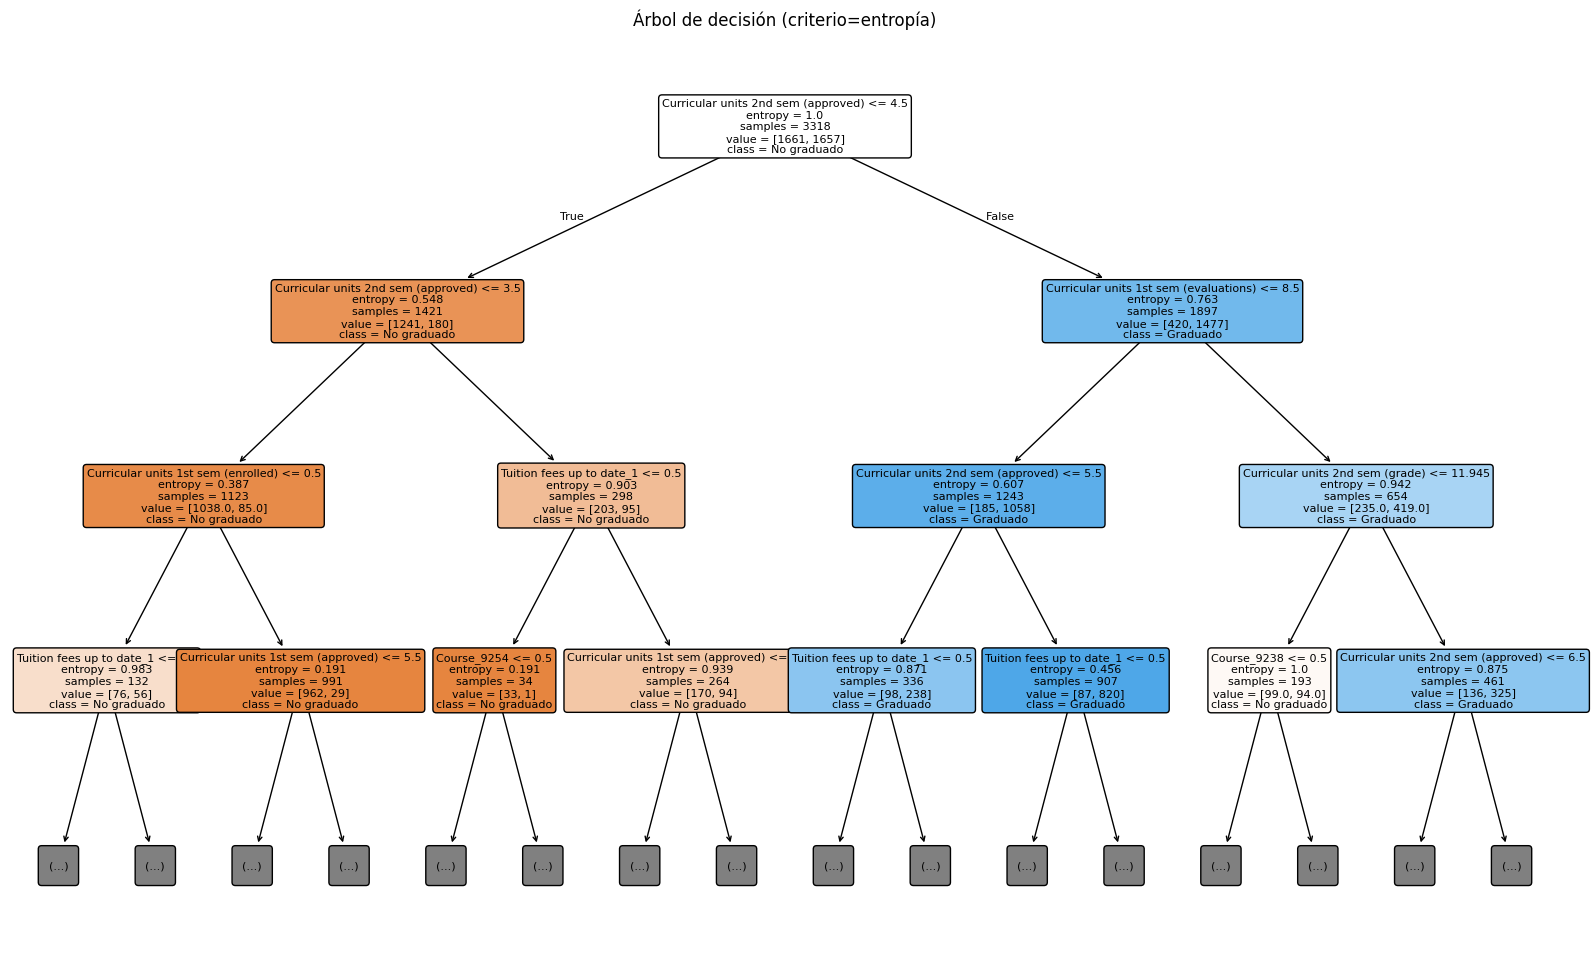

2) El árbol tiene 711 nodos en total, de los cuales 356 son hojas.



In [35]:
#Dibujar el árbol completo y mostrar número de nodos y hojas
plt.figure(figsize=(20, 12))
plot_tree(arbol,
          max_depth = 3,
          feature_names=columnas,
          class_names=['No graduado','Graduado'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Árbol de decisión")
plt.show()

n_nodos = info_arbol.node_count
n_hojas = info_arbol.n_leaves
print(f"2) El árbol tiene {n_nodos} nodos en total, de los cuales {n_hojas} son hojas.\n")


### Rendimiento

Se mide que tan bien generaliza el árbol entrenado. Se calculo el *accuracy* que resulta ser de aprox 0.8, esto quiere decir que el modelo clasifica correctamente el 80% de los alumnos graduados y no graduados, luego el *F1-score* indica un valor de aprox 0.8 también, por lo que podemos decir que hay un buen equilibrio en la capacidad del modelo de clasificar cada clase.

Luego, las características más influyentes en el modelo es ''Curricular units 2nd sem(approved)'' con una importancia de aprox 0.39, esto refleja que el 39% de la decisión proviene de este criterio, luego está ''Admission grade'' con aprox 0.05. Por lo que la cantidad de asignaturas aprobadas en el segundo semestre y la nota de admisión son las variables que más contribuyen a la capacidad del árbol de distinguir estudiantes que se graduarán o no.

In [38]:
#Evaluación en test
y_pred = arbol.predict(x_test)
acc     = accuracy_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
print("Desempeño en el conjunto de prueba:")
print(f"   Accuracy: {acc:.4f}")
print(f"   F1-score: {f1:.4f}\n")

#Top-2 features por importancia
importances   = arbol.feature_importances_
serie_imp     = pd.Series(importances, index=columnas)
top2_features = serie_imp.sort_values(ascending=False).head(2)

for feat, imp in top2_features.items():
    print(f" Features relevantes:   - {feat}: importancia = {imp:.4f}")

Desempeño en el conjunto de prueba:
   Accuracy: 0.7911
   F1-score: 0.7965

 Features relevantes:   - Curricular units 2nd sem (approved): importancia = 0.3877
 Features relevantes:   - Admission grade: importancia = 0.0485


##Podado

El podado es una técnica para controlar el sobre-ajuste, consiste en eliminar aquellas ramas que aportan poca ganancia informativa.*Sklearn* implementa el podado por *cost complexity pruning* introduciendo un parametro de penalización $\alpha$. A medida que $\alpha$ crece, el término penalizador hace que el árbol óptimo sea más pequeño a cambio de permitir un ligero aumento de impureza, con el fin de mejorar la capacidad de generalización.

Cada $\alpha_i$ define un árbol candidato en el que se han eliminado las ramas cuyo beneficio añadido no supera ese umbral de penalización.

Se repite el entrenamiento para cada $\alpha$ de la lista, y guardamos el número de hojas que muestra la complejidad del modelo, y el *accuracy* y el *F1-score* evaluados sobre el conjunto de prueba.

El resultado es una familia de árboles que va desde el más grande (sin podar), hasta los más sencillos. Gráficando el número de hojas, el accuracy y el F1 en función de $alpha$ podemos identificar el punto óptimo de complejidad.


In [40]:
# Calcular todos los α relevantes para la poda
path = arbol.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# A menudo el último alpha produce un árbol de una sola hoja: lo quitamos
ccp_alphas = ccp_alphas[:-1]

# Entrenar un árbol podado para cada α, y recoger métricas
clfs = []
n_leaves = []
test_acc = []
test_f1  = []

for alpha in ccp_alphas:
    clf_ = DecisionTreeClassifier(
        criterion='entropy',
        random_state=42,
        ccp_alpha=alpha
    )
    clf_.fit(x_train, y_train)
    clfs.append(clf_)
    # Cuenta hojas del árbol
    n_leaves.append(clf_.tree_.n_leaves)
    # Predicción sobre test
    y_pred = clf_.predict(x_test)
    test_acc.append(accuracy_score(y_test, y_pred))
    test_f1 .append(f1_score (y_test, y_pred))




### Influencia de $\alpha$

En estos gráficos se observa el efecto de la poda en el árbol de decisión. El primer gráfico *Hojas vs $\alpha$* muestra que, al incrementar el parametro de penalización, el número de hojas disminuye de manera escalonada, lo cual tiene sentido porque estamos empujando al árbol a prescindir de partciones con escasa ganancia informativa.
Luego, en los siguientes gráficos aparece una especie de curva con un pico en un intervalo especifico, entre aprox 0.002 y 0.005, entre este intervalo se presenta el punto optimo, donde tanto el accuracy como el F1 alcanzan su máximo, en esta zona la poda elimina ramas que solo capturan ruido del entrenamiento, manteniendo las particiones mas informativas y consiguiendo así el árbol más simple.

Esto lo podemos confirmar con los cálculos analiticos. Al seleccionar el árbol con mejor *F1* en el conjunto de prueba, se identifica el indice del valor máximo de *F1* entre todos los árboles generados para distintos valores de $\alpha$, a partir de este indice se extrae el valor de $\alpha$ y el clasificador correspondiente, asi como las metricas de desempeño, el cual para *F1* es de aprox 0.83 y un *accuracy* de 0.82 aprox. Podemos ver que además la cantidad de hojas son 50. Si comparamos este modelo con el anterior que no incluia el podado, vemos que además de disminuir la complejidad, el desempeño mejoro, mejorando así la capacidad de generalización.

Luego se calculan las 'features relevantes' del árbol elegido, esta son la cantidad de asignaturas aprobadas en el segundo semestre, con un peso de 0.65 aprox, y el número de asignaturas en las que el alumno se matriculo en el primer semestre que es de aprox 0.06.
Este procedimiento como vimos, permite encontrar el punto en el que la penalización por tamaño minimiza el sobreajuste sin sacrificar rendimiento, incluso mejorandolo aunque sea un poco.

In [55]:
# Seleccionar el árbol con mejor F1 en test y mostrar top-2 features
best_idx   = np.argmax(test_f1)
best_alpha = ccp_alphas[best_idx]
best_clf   = clfs[best_idx]
best_f1    = test_f1[best_idx]
best_acc   = test_acc[best_idx]
best_leaves= n_leaves[best_idx]

print(f"Mejor árbol podado (mayor F1):")
print(f"  alpha  = {best_alpha:.6f}")
print(f"  F1-score   = {best_f1:.4f}")
print(f"  Accuracy   = {best_acc:.4f}")
print(f"  # Hojas    = {best_leaves}")

# Top-2 features por importancia
feat_imp = pd.Series(
    best_clf.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False).head(2)

print("\nDos features más relevantes en el mejor árbol:")
for feat, imp in feat_imp.items():
    print(f" - {feat}: importancia = {imp:.4f}")

Mejor árbol podado (mayor F1):
  alpha  = 0.002156
  F1-score   = 0.8271
  Accuracy   = 0.8201
  # Hojas    = 50

Dos features más relevantes en el mejor árbol:
 - Curricular units 2nd sem (approved): importancia = 0.6475
 - Curricular units 1st sem (enrolled): importancia = 0.0592


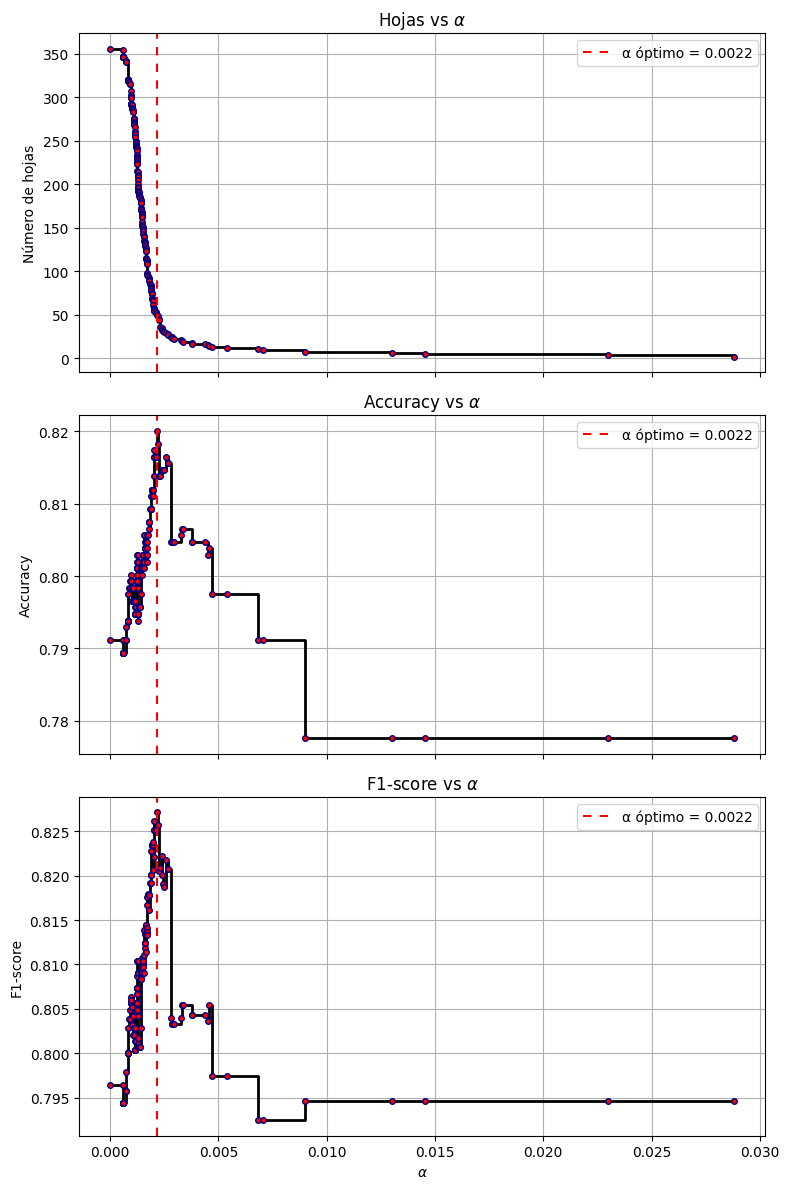

In [53]:
# Suponiendo que ccp_alphas, n_leaves, test_acc y test_f1 ya están definidos
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

# 1) Número de hojas vs alpha
axes[0].plot(ccp_alphas, n_leaves, marker='o', drawstyle='steps-post', color = 'black',
             linewidth = 2, markersize = 4, markeredgecolor='navy',
    markerfacecolor='red' )
axes[0].set_ylabel('Número de hojas')
axes[0].set_title(r'Hojas vs $\alpha$')
axes[0].grid(True)

# 2) Accuracy vs alpha
axes[1].plot(ccp_alphas, test_acc, marker='o', drawstyle='steps-post', color = 'black',
             linewidth = 2, markersize = 4, markeredgecolor='navy',
    markerfacecolor='red' )
axes[1].set_ylabel('Accuracy')
axes[1].set_title(r'Accuracy vs $\alpha$')
axes[1].grid(True)

# 3) F1-score vs alpha
axes[2].plot(ccp_alphas, test_f1, marker='o', drawstyle='steps-post', color = 'black',
             linewidth = 2, markersize = 4, markeredgecolor='navy',
    markerfacecolor='red' )
axes[2].set_xlabel(r'$\alpha$')
axes[2].set_ylabel('F1-score')
axes[2].set_title(r'F1-score vs $\alpha$')
axes[2].grid(True)

for ax in axes:
    ax.axvline(
        x=best_alpha,
        color='red',
        linestyle='--',
        linewidth=1.5,
        dashes=(4, 4),    # 4 puntos encendidos, 4 apagados
        label=f'α óptimo = {best_alpha:.4f}'
    )
    # Para que aparezca la etiqueta en la leyenda de uno de los subplots:
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

##Bosque Aleatorio

Los bosques aleatorios surgen como una extensión de los árboles de decisión para reducir el **overfitting**, aunque las condiiciones de poda ayudan a controlar el sobre-ajuste, muchas veces no es suficiente debido a la alta varianza de los árboles individuales. Para solucionarlo se utiliza la técnica de **Bagging**, que consiste en entrenar multiples arboles de decisión independientes sobre diferentes muestras de entrenamiento y combinar sus predicciones. Un conjunto de multiples árboles entrenandos con Bagging se denomina **bosque aleatorio**.


### Random Forest Classifier

Se construye un *Random Forest Classifier* formado por 20 árboles de decisión independientes, cada uno entrenado sobre una muestra aleatoria del conjunto de entrenamiento.

Al combinar sus predicciones por votación, el bosque tiende a reducir la varianza y a mitigar el sobre-ajuste. Tras ajustar el modelo, se evalua su desempeño sobre el conjunto de prueba, se obtiene un *accuracy* de aprox. 0.82 y un *F1-score* de 0.83, lo que indica un buen rendimiento. Finalmente, al extraer las importancias de las variables, se observa que las dos caracteristicas más relevantes para la predicción de graduación son, el número de asignaturas aprobadas en el segundo semestre y la cantidad de materias en que el estudiante se matriculo en el primer semestre.  Este resultado refuerza la interpretación de que el rendimiento académico medido a lo largo de ambos semestres es el principal determinante para anticipar la probabilidad de graduación.

In [56]:

# Entrenar Random Forest con 20 árboles
rf = RandomForestClassifier(
    n_estimators=20,
    criterion='entropy',
    random_state=42,
    n_jobs=-1
)
rf.fit(x_train, y_train)

# Evaluar accuracy y F1 sobre el conjunto de test
y_pred = rf.predict(x_test)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)

print(f"Accuracy en test: {acc:.4f}")
print(f"F1-score en test: {f1:.4f}")

# Top-2 features más importantes
importances = pd.Series(
    rf.feature_importances_,
    index= x_train.columns
).sort_values(ascending=False)

top2 = importances.head(2)
print("\nDos features con mayor importancia:")
for feat, imp in top2.items():
    print(f"- {feat}: {imp:.4f}")

Accuracy en test: 0.8237
F1-score en test: 0.8264

Dos features con mayor importancia:
- Curricular units 2nd sem (approved): 0.1509
- Curricular units 2nd sem (grade): 0.1139


## Comparación de los 3 modelos

El **arbol de decisión sin restricciones** crecio hasta 711 nodos y 356 hojas, logrando un accuracy de 0.8 y un F1 de 0.8 en test. Este tamaño tan elevado indica sobreajuste, por lo que el modelo memoriza patrones y ruido de los datos de entrenamiento.

Al **podar** el árbol mediante *cost-complexity pruning*, su tamaño se reduce drásticamente a tan solo 50 hojas, y al mismo tiempo mejora el rendimiento. La poda elimina particiones poco significativas, mejorando la complejidad del modelo.

Por último, el Random Forest de 20 árboles combina bagging y submuestreo aleatorio de variables para reducir la varianza sin aumentar el sesgo, consiguiendo métricas comparables.

En los tres modelos, la métrica de  **Curricula units 2nd sem (approved)**sale siempre como la caracteristica más relevante, lo cual subraya que el número de asignaturas aprobadas en el segundo semestre es el principal predictor de graduación.